## Module 4 - In this jupyter notebook, target productivity and productivity gaps are calculated

**Last update: 07-Mar-2025**

[![Open in Colab](https://raw.githubusercontent.com//wateraccounting/WaPORMOOC/main/images/colab-badge.png)](https://colab.research.google.com/github/wateraccounting/WaPORIPA/blob/main/Notebooks_v1.0/Module_4_ProductivityGaps.ipynb?target=\"_blank\")

* Step 1 - Set up
* Step 2 - Calculate the target productivity
* Step 3 - Identify bright spots
* Step 4 - calculate productivity gaps
* Step 5 - Downlaod the results
**=============================================================================================**
![title](https://github.com/wateraccounting/WAPORWP/blob/master/Notebooks/img/Fig5.PNG?raw=true)
**=============================================================================================**

## **1 Import packages/libraries**

In [1]:
!pip install rioxarray --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.4 MB/s eta 0:00:00


In [2]:
import os                                               # Provides functions to interact with the operating system
import glob                                             # Used to find file paths matching a specified pattern
import numpy as np                                      # For numerical computations and array manipulation
import pandas as pd                                     # For data manipulation and analysis, especially with DataFrames
from matplotlib.patches import Rectangle                # Allows drawing rectangles in plots, useful for custom legends or highlighting areas
import matplotlib.lines as mlines                       # Creates lines in plots, helps sync colorbars and visual elements
from matplotlib import colors                           # Manages color maps and normalizing data to colors
from mpl_toolkits.axes_grid1 import make_axes_locatable # Helps align colorbars with plots and maintain consistent layout
from matplotlib import pyplot as plt                    # Core library for creating visualizations and plots
import rioxarray                                        # For reading and writing geospatial raster data with raster and CRS support
import matplotlib.pyplot as plt                         # Core plotting functionality from Matplotlib (included twice, can remove one)
from mpl_toolkits.axes_grid1 import make_axes_locatable # Repeated import for syncing colorbars with plot dimensions

# import sys                                              # Provides access to system-specific parameters and functions

## Set filepaths / configuration
### Expected folder structure
This code expects the output of Module 3 (Yield_WP_IPA.zip) to be in the following structure when unzipped:
```
WaPORAPI/
├── content/
│   └── output/
│       ├── TBP_season/     # Generated by Module 3
│       ├── yield_season/   # Generated by Module 3
│       ├── BWP_season/     # Generated by Module 3
│       └── Cwp_season/     # Generated by Module 3
├── ...
...
```

### Define File Structure
#### When do I update these values?
If you are using the data provided by the lecturers on Colab, do not change these variables. However, if you are running locally, or working with your own files which have a different file structure, update the following variables.

In [ ]:
# === CONFIGURATION — update these for your setup ===

# Project root (parent of Notebooks_v1.0/). 
# On Colab will return: /content and locally: repo root.
dir_proj = os.path.split(os.getcwd())[0]

# WaPOR data directory (containing L3-AETI-D, L3-T-D, L3-NPP-D subdirs)
dir_data = "/content/content/output/"   # Colab default 
# dir_data = "test-data/content/output/"          # Local alternative (relative to dir_proj)

# Output directory for Module_4 results
dir_out = "/content/output/"            # Colab default
# dir_out = "test-data/content/output/" # Local alternative (relative to dir_proj)


# Season definitions — edit SOS/EOS dates for your growing season
season_periods = {
    'season1': {'SOS': '2022-11-01', 'EOS': '2023-06-01'}
}

## **2 Upload and import data**

In [3]:
# Upload the seasonal TBP, Yield, WP files (output of Module 3: Yield_WP_IPA.zip).
from google.colab import files
uploaded = files.upload()

Saving Yield_WP_IPA.zip to Yield_WP_IPA.zip


In [ ]:
# # Mount/connect/ your Google Drive to Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
!unzip '/content/Yield_WP_IPA.zip' -d '/content'

Archive:  /content/Yield_WP_IPA.zip
   creating: /content/content/output/
   creating: /content/content/output/Adequacy/
  inflating: /content/content/output/Adequacy/Adequacy_ETc_season1_2022-11-01_to_2023-06-01.tif  
   creating: /content/content/output/RWD/
  inflating: /content/content/output/RWD/RWD_season1_2022-11-01_to_2023-06-01.tif  
   creating: /content/content/output/yield_season/
  inflating: /content/content/output/yield_season/yield_season1_2022-11-01_to_2023-06-01.tif  
   creating: /content/content/output/Beneficial_fraction/
  inflating: /content/content/output/Beneficial_fraction/BF_season1_2022-11-01_to_2023-06-01.tif  
   creating: /content/content/output/Cwp_season/
  inflating: /content/content/output/Cwp_season/cWP_season1_2022-11-01_to_2023-06-01.tif  
   creating: /content/content/output/BWP_season/
  inflating: /content/content/output/BWP_season/BWP_season1_2022-11-01_to_2023-06-01.tif  
   creating: /content/content/output/TBP_season/
  inflating: /content/c

In [ ]:
# used to verify that input folders exist and have content 
def verify_file_paths(file_name, folder, files=None):

    # check if folder exists
    if not os.path.isdir(folder):
        print(f"WARNING: {file_name} folder not found: {folder}\n")
        return 
    
    print(f"Folder of input {file_name} data: {folder}")

    # if files aren't passed in, get them dynamically
    # by checking for tifs in this folder
    if not files: 
        files = sorted(glob.glob(folder + '/*.tif'))  

    # count number of tifs and throw error if empty
    print(f"Number of {file_name} files: {len(files)}")
    if files:
        print(f"First file: {files[0]}\n")
    else:
        print("WARNING: No files found!\n")

In [5]:
# Set up paths to access the seasonal TBP, yield, WPb, cWP data
input_AGBMfolder  = os.path.join(dir_proj, dir_data, "TBP_season")
input_AGBMfhs     = sorted(glob.glob(input_AGBMfolder + '/*.tif'))

input_WPbfolder   = os.path.join(dir_proj, dir_data, "BWP_season")
input_WPbfhs      = sorted(glob.glob(input_WPbfolder + '/*.tif'))

input_Yieldfolder  = os.path.join(dir_proj, dir_data, "yield_season")
input_Yieldfhs     = sorted(glob.glob(input_Yieldfolder + '/*.tif'))

input_WPyfolder   = os.path.join(dir_proj, dir_data, "Cwp_season")
input_WPyfhs      = sorted(glob.glob(input_WPyfolder + '/*.tif'))

# Verify input files
verify_file_paths('TBP', input_AGBMfolder, input_AGBMfhs)
verify_file_paths('BWP', input_WPbfolder, input_WPbfhs)
verify_file_paths('Yield', input_Yieldfolder, input_Yieldfhs)
verify_file_paths('cWP', input_WPyfolder, input_WPyfhs)

# Print all paths
# input_AGBMfhs, input_WPbfhs, input_Yieldfhs, input_WPyfhs

(['/content/content/output/TBP_season/TBP_season1_2022-11-01_to_2023-06-01.tif'],
 ['/content/content/output/BWP_season/BWP_season1_2022-11-01_to_2023-06-01.tif'],
 ['/content/content/output/yield_season/yield_season1_2022-11-01_to_2023-06-01.tif'],
 ['/content/content/output/Cwp_season/cWP_season1_2022-11-01_to_2023-06-01.tif'])

In [6]:
# season_periods is defined in the configuration cell above

## **3 - Calculate the target productivity**

## i) Define function to plot productivity targets

In [7]:
def plotProductivityTargets(x, y, WP, title1, xlable1, ylable1, title2, xlable2, ylable2, percentile = 90):
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

    # Scatter plot
    ax1.scatter(y, WP, marker='*', color="grey")
    ax1.scatter(np.nanpercentile(y, percentile), np.nanpercentile(WP, percentile), marker='*', color='black', s=100)

    ax1.axvline(np.nanpercentile(y, percentile), color="#EE6666", linestyle="--")
    ax1.axhline(np.nanpercentile(WP, percentile), color="#EE6666", linestyle="--")

    # Histogram
    counts, bins, patches = ax2.hist(WP, bins=100, facecolor='skyblue', edgecolor='none', histtype="bar")

    # Add legend
    fakeLine = plt.Line2D([0, 0], [0, 1], color="#EE6666", linestyle='--')
    fakemark = mlines.Line2D([], [], color='black', marker='*', markersize=10)
    ax2.legend([fakeLine, fakemark], [f"{percentile} percentile", 'Productivity target'])

    # Colouring histogram bars based on percentiles
    lower_bound, upper_bound = np.nanpercentile(WP, [10, percentile])
    for patch, leftside, rightside in zip(patches, bins[:-1], bins[1:]):
        if rightside < lower_bound:
            patch.set_facecolor('#EE6666')
        elif leftside > upper_bound:
            patch.set_facecolor('green')

    # Create legend
    handles = [Rectangle((0, 0), 1, 1, color=c, ec="k") for c in ['#EE6666', 'green']]
    labels = ["0-10 Percentile", f">{percentile} Percentile"]
    plt.legend(handles, labels)

    # Titles and labels
    ax1.set_title(title1, fontsize=14)
    ax1.set_xlabel(xlable1, fontsize=13)
    ax1.set_ylabel(ylable1, fontsize=13)

    ax2.set_title(title2, fontsize=14)
    ax2.set_xlabel(xlable2, fontsize=13)
    ax2.set_ylabel(ylable2, fontsize=13)

    return None

## ii) Define function to extract season and date range from the filename

In [8]:
# Function to extract season and date range from the filename
def extract_season_and_dates(file_path):

  """
This function, extract_season_and_dates(), extracts the season and date range from a raster file name.
The function assumes the file name follows a pattern like "AETI_season1_2022-11-01_to_2023-06-01.tif".
It splits the filename into parts to retrieve the season (season1) and the date range (2022-11-01 to 2023-06-01), then returns them as output.
  """

  # Extract the filename
  filename = os.path.basename(file_path)
  # Assuming the pattern is "AETI_season1_2022-11-01_to_2023-06-01.tif"
  parts = filename.split('_')

  # Extract the season (assumes "season1" is the second part)
  season = parts[1]  # e.g., "season1"

  # Extract the date range (assumes it's the third and fourth parts)
  start_date = parts[2]  # e.g., "2022-11-01"
  end_date = parts[4].replace('.tif', '')  # e.g., "2023-06-01"

  # Format the date range
  date_range = f"{start_date} to {end_date}"

  return season, date_range

## iii) Calculate the target biomass and target biomass water productivity

In [9]:
# Target productivity
TargetPercentile = 90

In [10]:
# Import the relevant input data
input_AGBMfolder  = os.path.join(dir_proj, dir_data, "TBP_season")
input_AGBMfhs     = sorted(glob.glob(input_AGBMfolder + '/*.tif'))

input_WPbfolder   = os.path.join(dir_proj, dir_data, "BWP_season")
input_WPbfhs      = sorted(glob.glob(input_WPbfolder + '/*.tif'))

# Verify input files
verify_file_paths('TBP', input_AGBMfolder, input_AGBMfhs)
verify_file_paths('BWP', input_WPbfolder, input_WPbfhs)

,Season,Target_biomass,Target_WPb
0,season1,14.0,2.7


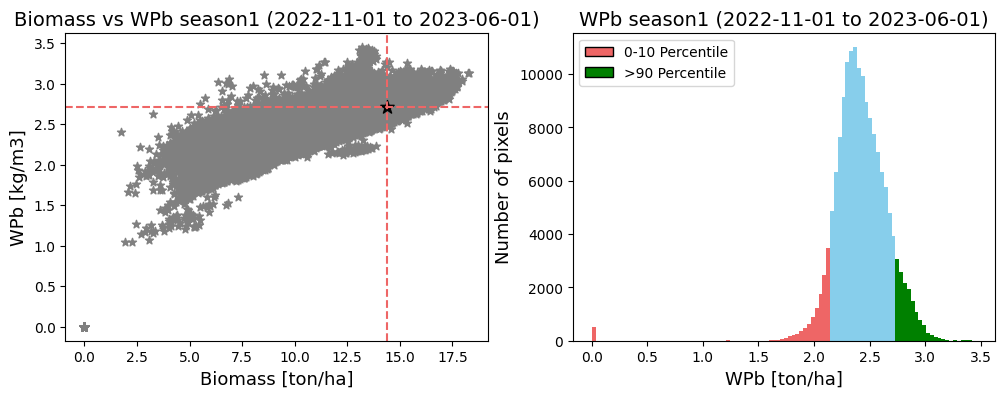

In [11]:
"""
This script processes seasonal data to calculate target biomass and WPb levels.
It reads AGBM, and WPb from raster files, reshapes the data, and computes targets based on a specified percentile.
The season and date range are extracted for labeling, and scatter plots and histograms are generated to visualize biomass and WPb.
Results are saved in a DataFrame.
"""
Season        = []
BiomassTarget = []
WPbTarget     = []

for in_fhAGBM, in_fhWPb in zip(input_AGBMfhs, input_WPbfhs):
    # Open the files with rioxarray
    AGBM_ds = rioxarray.open_rasterio(in_fhAGBM)
    WPb_ds = rioxarray.open_rasterio(in_fhWPb)

    # Convert to numpy arrays
    AGBM = AGBM_ds.values[0]
    WPb = WPb_ds.values[0]

    # Reshape the arrays
    Biomass_1D = AGBM.ravel()
    WPb_1D = WPb.ravel()

    # Targets productivity
    Target_biomass = round(np.nanpercentile(Biomass_1D, TargetPercentile), 0)  # Target productivity yield
    TargetWP = round(np.nanpercentile(WPb_1D, TargetPercentile), 1)            # Target productivity WP

    # Extract season and date range from the filename
    season, date_range = extract_season_and_dates(in_fhAGBM)

    Season.append(season)
    BiomassTarget.append(Target_biomass)
    WPbTarget.append(TargetWP)

    # Scatter plot of Yield vs WP and histogram of WP for the season
    title1 = f'Biomass vs WPb {season} ({date_range})'
    xlable1 = 'Biomass [ton/ha]'
    ylable1 = 'WPb [kg/m3]'

    title2 = f'WPb {season} ({date_range})'
    xlable2 = 'WPb [ton/ha]'
    ylable2 = 'Number of pixels'

    plotProductivityTargets(Biomass_1D, Biomass_1D, WPb_1D, title1, xlable1, ylable1, title2, xlable2, ylable2, TargetPercentile)

# Save the data into dataframe - tabular form
data_tuples = list(zip(Season, BiomassTarget, WPbTarget))
df_targets = pd.DataFrame(data_tuples, columns=['Season', 'Target_biomass', 'Target_WPb'])

df_targets

## iv) Calculate the target crop yield and target crop water productivity

In [12]:
# Target productivity
TargetPercentile = 90

In [13]:
# Import the relevant input data
input_Yieldfolder  = os.path.join(dir_proj, dir_data, "yield_season")
input_Yieldfhs     = sorted(glob.glob(input_Yieldfolder + '/*.tif'))

input_WPyfolder   = os.path.join(dir_proj, dir_data, "Cwp_season")
input_WPyfhs      = sorted(glob.glob(input_WPyfolder + '/*.tif'))

# Verify input files
verify_file_paths('Yield', input_Yieldfolder, input_Yieldfhs)
verify_file_paths('cWP', input_WPyfolder, input_WPyfhs)

,Season,Target_yield,Target_WPy
0,season1,7.0,1.3


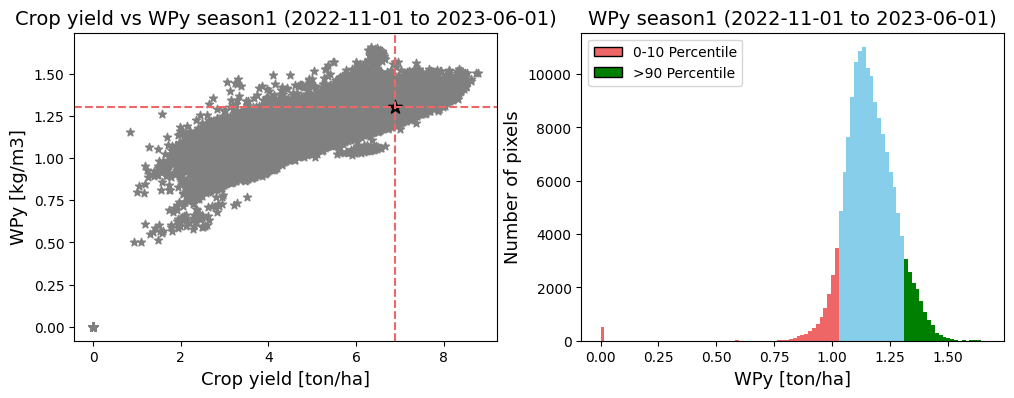

In [14]:
"""
This script processes seasonal data to calculate target crop yield and water productivity (WPy).
It reads yield, and WPy from raster files, reshapes the data, and computes target values based on a specified percentile.
The season and date range are extracted for labeling, and scatter plots and histograms are generated to visualize the relationship between yield and WPy.
Results are stored in a DataFrame for further analysis.
"""
# Read spatial information from the first input file using rioxarray
in_fh = input_Yieldfhs[0]

Season        = []
YieldTarget   = []
WPyTarget     = []

for in_fhYield, in_fhWPy in zip(input_Yieldfhs, input_WPyfhs):
    # Open the files with rioxarray
    Yield_ds = rioxarray.open_rasterio(in_fhYield)
    WPy_ds = rioxarray.open_rasterio(in_fhWPy)

    # Convert to numpy arrays
    Yield = Yield_ds.values[0]
    WPy = WPy_ds.values[0]

    # Reshape the arrays
    Yield_1D = Yield.ravel()
    WPy_1D = WPy.ravel()

    # Targets productivity
    Target_yield = round(np.nanpercentile(Yield_1D, TargetPercentile), 0)  # Yield at 90/95 percentile
    TargetWP = round(np.nanpercentile(WPy_1D, TargetPercentile), 1)       # WP at 90/95 percentile

    # Extract season and date range from the filename
    season, date_range = extract_season_and_dates(in_fhYield)

    Season.append(season)
    YieldTarget.append(Target_yield)
    WPyTarget.append(TargetWP)

    # Scatter plot of Yield vs WP and histogram of WP
    spatial_extent = (Yield_ds.x.min(), Yield_ds.x.max(), Yield_ds.y.min(), Yield_ds.y.max())
    title1 = f'Crop yield vs WPy {season} ({date_range})'
    xlable1 = 'Crop yield [ton/ha]'
    ylable1 = 'WPy [kg/m3]'

    title2 = f'WPy {season} ({date_range})'
    xlable2 = 'WPy [ton/ha]'
    ylable2 = 'Number of pixels'

    plotProductivityTargets(Yield_1D, Yield_1D, WPy_1D, title1, xlable1, ylable1, title2, xlable2, ylable2, TargetPercentile)

# Save the data into dataframe - tabular form
data_tuples = list(zip(Season, YieldTarget, WPyTarget))
df_targets = pd.DataFrame(data_tuples, columns=['Season', 'Target_yield', 'Target_WPy'])

df_targets


## **4 Identify bright spots (Map the bright spots in the study area)**
* The bright spots are idetified based on the target biomass and target biomass water productivity (WPb)

In [15]:
# Target productivity
TargetPercentile = 90

In [16]:
# Import the relevant input data
input_AGBMfolder  = os.path.join(dir_proj, dir_data, "TBP_season")
input_AGBMfhs     = sorted(glob.glob(input_AGBMfolder + '/*.tif'))

input_WPbfolder   = os.path.join(dir_proj, dir_data, "BWP_season")
input_WPbfhs      = sorted(glob.glob(input_WPbfolder + '/*.tif'))

verify_file_paths("TBP seasonal", input_AGBMfolder, input_AGBMfhs)
verify_file_paths("BWP seasonabl", input_WPbfolder, input_WPbfhs)

### Analyse and Visualize bright spots:

This script processes raster data for **Biomass (AGBM)**, and **Biomass Water Productivity (WPb)** for a specified season. The goal is to calculate and visualize target thresholds for Biomass and WPb, as well as highlight areas where both conditions are met. Below is a summary of the steps:

1. **Load & Process Data**: Open Biomass and WPb raster files with rioxarray, convert them to 2D NumPy arrays, reshape for percentile calculations, extract season and date from file names, and define spatial extent for geographic alignment.
2. **Calculate Thresholds**: Compute percentile-based and maximum values for Biomass and WPb.
3. **Plot thresholds and map bright spots**:
    - Figure 1: Areas where Biomass meets/exceeds the target.
    - Figure 2: Areas where WPb meets/exceeds the target.
    - Figure 3: Intersection of both conditions.
4. **Analyze & Visualize**: Calculate area percentages meeting each condition, print results, and display plots using subplots for side-by-side comparison.

### **Calculate and plot targets**

<>:51: SyntaxWarning: invalid escape sequence '\c'
<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:90: SyntaxWarning: invalid escape sequence '\c'
<>:91: SyntaxWarning: invalid escape sequence '\c'
<>:51: SyntaxWarning: invalid escape sequence '\c'
<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:90: SyntaxWarning: invalid escape sequence '\c'
<>:91: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_362/937071922.py:51: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_xlabel('Longitude ($^{\circ}$ East)', fontsize=12)
/tmp/ipykernel_362/937071922.py:52: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_ylabel('Latitude ($^{\circ}$ North)', fontsize=12)
/tmp/ipykernel_362/937071922.py:90: SyntaxWarning: invalid escape sequence '\c'
  ax3.set_xlabel('Longitude ($^{\circ}$ East)', fontsize=12)
/tmp/ipykernel_362/937071922.py:91: SyntaxWarning: invalid escape sequence '\c'
  ax3.set_ylabel('Latitude ($^{\circ}$ North)', fontsize=12)


Percentage of area meeting Biomass target: 13.32%
Percentage of area meeting WPb target: 11.36%
Percentage of area meeting both Biomass and WPb targets: 5.05%


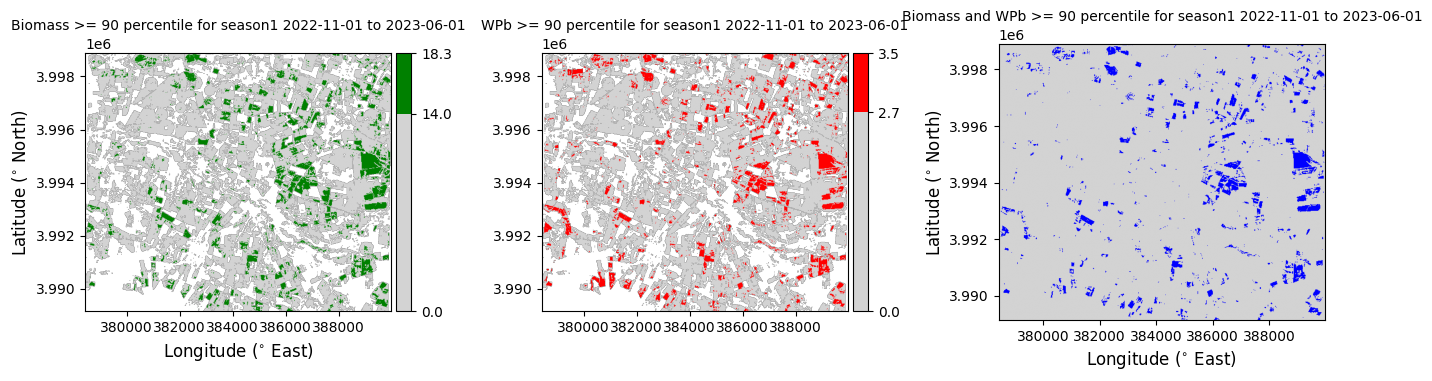

In [17]:
TargetPercentile = 90

#  calculate and plot targets

for in_fhAGBM, in_fhWPb in zip(input_AGBMfhs, input_WPbfhs):
    # Step 1: Open the files using rioxarray
    AGBM_ds = rioxarray.open_rasterio(in_fhAGBM)
    WPb_ds = rioxarray.open_rasterio(in_fhWPb)

    # Step 2: Convert raster data to numpy arrays
    AGBM = AGBM_ds.values[0]
    WPb = WPb_ds.values[0]

    # Step 3: Reshape arrays into 1D for percentile calculations
    Biomass_1D = AGBM.ravel()
    WPb_1D = WPb.ravel()

    # Step 4: Calculate target thresholds based on specified percentiles
    TargetBiomass = round(np.nanpercentile(Biomass_1D, TargetPercentile), 0)
    TargetWP = round(np.nanpercentile(WPb_1D, TargetPercentile), 1)
    maxBiomass = round(np.nanmax(AGBM), 1)
    maxWPb = round(np.nanmax(WPb), 1)

    # Step 5: Extract season and date range for labeling from the file name
    season, date_range = extract_season_and_dates(in_fhAGBM)

    # Step 6: Prepare for plotting - Define spatial extent
    spatial_extent = (AGBM_ds.x.min(), AGBM_ds.x.max(), AGBM_ds.y.min(), AGBM_ds.y.max())

    # Create subplots for three figures
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(16, 8))

    ### Figure 1: Biomass >= target
    # Calculate the percentage for Biomass >= target
    valid_biomass_pixels = np.count_nonzero(~np.isnan(AGBM))  # Count non-NaN pixels
    target_biomass_pixels = np.count_nonzero(AGBM >= TargetBiomass)  # Count pixels where biomass >= target
    percentage_biomass = (target_biomass_pixels / valid_biomass_pixels) * 100 if valid_biomass_pixels > 0 else 0

    print(f'Percentage of area meeting Biomass target: {percentage_biomass:.2f}%')

    # Plot Biomass >= target
    cmap1 = colors.ListedColormap(['lightgrey', 'green'])
    bounds1 = [0, TargetBiomass, maxBiomass]
    norm1 = colors.BoundaryNorm(bounds1, cmap1.N)

    img1 = ax1.imshow(AGBM, cmap=cmap1, norm=norm1, extent=spatial_extent)
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(img1, spacing='proportional', ax=ax1, cax=cax1)
    ax1.set_title(f'Biomass >= {TargetPercentile} percentile for {season} {date_range}', fontsize=10)
    ax1.set_xlabel('Longitude ($^{\circ}$ East)', fontsize=12)
    ax1.set_ylabel('Latitude ($^{\circ}$ North)', fontsize=12)

    ### Figure 2: WPb >= target
    # Calculate the percentage for WPb >= target
    valid_WPb_pixels = np.count_nonzero(~np.isnan(WPb))  # Count non-NaN pixels
    target_WPb_pixels = np.count_nonzero(WPb >= TargetWP)  # Count pixels where WPb >= target
    percentage_WPb = (target_WPb_pixels / valid_WPb_pixels) * 100 if valid_WPb_pixels > 0 else 0

    print(f'Percentage of area meeting WPb target: {percentage_WPb:.2f}%')

    # Plot WPb >= target
    cmap2 = colors.ListedColormap(['lightgrey', 'red'])
    bounds2 = [0, TargetWP, maxWPb]
    norm2 = colors.BoundaryNorm(bounds2, cmap2.N)

    img2 = ax2.imshow(WPb, cmap=cmap2, norm=norm2, extent=spatial_extent)
    divider2 = make_axes_locatable(ax2)
    cax2 = divider2.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(img2, spacing='proportional', ax=ax2, cax=cax2)
    ax2.set_title(f'WPb >= {TargetPercentile} percentile for {season} {date_range}', fontsize=10)

    ### Figure 3: Intersection of Biomass and WPb >= target
    # Areas that meet both biomass and WPb targets will be blue, others will be light grey.
    Biomass_WPb_targetSpots = np.where((AGBM >= TargetBiomass) & (WPb >= TargetWP), 1, 0)  # Intersection of biomass and WPb targets

    # Calculate the percentage for Biomass and WPb >= target
    valid_pixels = np.count_nonzero(~np.isnan(Biomass_WPb_targetSpots))  # Count non-NaN pixels
    target_pixels = np.count_nonzero(Biomass_WPb_targetSpots == 1)  # Count pixels meeting both conditions
    percentage_intersection = (target_pixels / valid_pixels) * 100 if valid_pixels > 0 else 0

    print(f'Percentage of area meeting both Biomass and WPb targets: {percentage_intersection:.2f}%')

    # Plot the third figure
    cmap3 = colors.ListedColormap(['lightgrey', 'blue'])
    norm3 = colors.BoundaryNorm([0, 1, 2], cmap3.N)  # Adjust the bounds for lightgrey and blue

    img3 = ax3.imshow(Biomass_WPb_targetSpots, cmap=cmap3, norm=norm3, extent=spatial_extent)
    ax3.set_title(f'Biomass and WPb >= {TargetPercentile} percentile for {season} {date_range}', fontsize=10)
    ax3.set_xlabel('Longitude ($^{\circ}$ East)', fontsize=12)
    ax3.set_ylabel('Latitude ($^{\circ}$ North)', fontsize=12)

    # Adjust layout and display the plots
    plt.subplots_adjust(wspace=0.4)
    plt.show()


## **5 Calculate productivity gaps**
* i) Biomass gaps and biomass WP gaps
* ii)Crop yield gaps and crop WP gaps

### **i) Biomass gaps and biomass water productivity gaps**

## * Import the input data (biomass and WPb raster data)

In [18]:
# Import relevant data
input_AGBMfolder  = os.path.join(dir_proj, dir_data, "TBP_season")
input_AGBMfhs     = sorted(glob.glob(input_AGBMfolder + '/*.tif'))

# Verify input files
verify_file_paths('TBP', input_AGBMfolder, input_AGBMfhs)

## ** Output folder: Make one or connect to the existing one

In [19]:
# Create output folders
output_folder1 = os.path.join(dir_proj, dir_out, "BiomassGaps")
output_folder2 = os.path.join(dir_proj, dir_out, "WPbgaps")

for folder in [output_folder1, output_folder2]:
    os.makedirs(folder, exist_ok=True)

output_folder1, output_folder2

('/content/output/BiomassGaps', '/content/output/WPbgaps')

## *** Calculate biomass gaps

In [20]:
# Define target productivity
TargetPercentile = 90

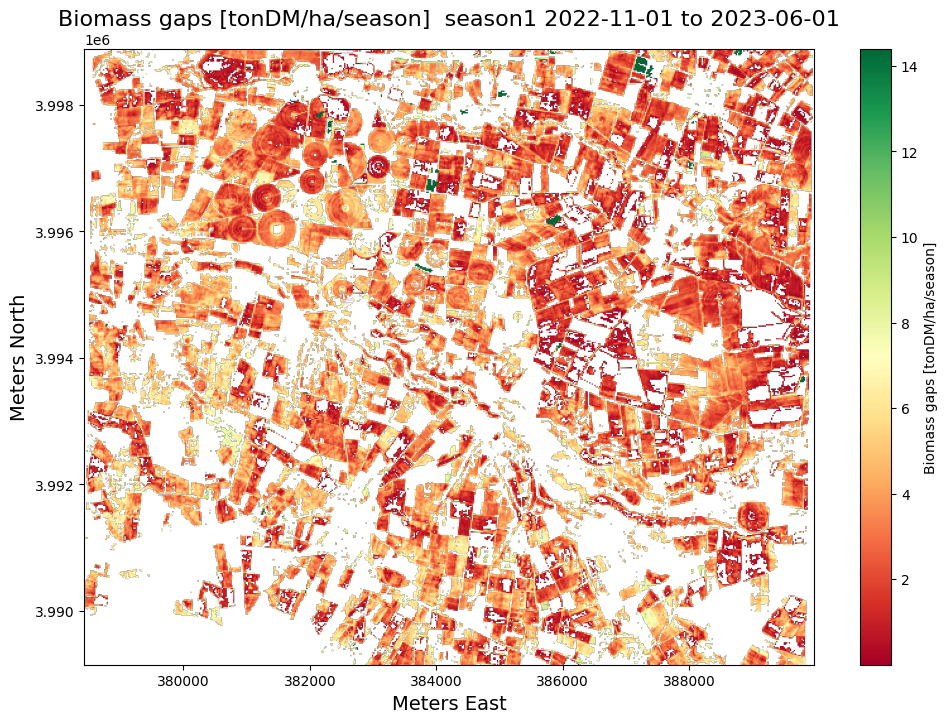

In [21]:

for in_fhAGBM in input_AGBMfhs:
    # Open the AGBM file with rioxarray
    AGBM_ds = rioxarray.open_rasterio(in_fhAGBM)

    # Convert to numpy array
    AGBM = AGBM_ds.values[0]  # assuming the first band is used

    # Productivity targets and productivity gaps
    Biomass_1D = AGBM.ravel()  # Reshape the array to 1D
    TargetBiomass = round(np.nanpercentile(Biomass_1D, TargetPercentile), 1)
    Biomassgap = np.where(AGBM < TargetBiomass, TargetBiomass - AGBM, np.nan)

    # Add an extra dimension to match the expected shape (1, 893, 1061)
    Biomassgap = Biomassgap[np.newaxis, :, :]

    # Identify the date from the file name
    date = os.path.basename(in_fhAGBM).split('.')[0].replace('TBP', '').replace('_', ' ')

    # Check if 'pywapor' is in the file name, and remove it if it exists
    if 'pywapor' in date:
        date = date.replace('pywapor', '')

    # Save yield gap
    output_folder = output_folder1
    basename = os.path.basename(in_fhAGBM).replace('TBP', 'BiomassGaps')
    output_fn = os.path.join(output_folder, basename)

    # Save the Biomass gap as a GeoTIFF using rioxarray
    Biomassgap_ds = AGBM_ds.copy(data=Biomassgap)
    Biomassgap_ds.rio.to_raster(output_fn)

    spatial_extent = (AGBM_ds.x.min(), AGBM_ds.x.max(), AGBM_ds.y.min(), AGBM_ds.y.max())
    # Plot the raster map
    plt.figure(figsize=(12, 8))
    plt.imshow(Biomassgap[0], cmap='RdYlGn', vmin=np.nanmin(Biomassgap), vmax=np.nanmax(Biomassgap), extent=spatial_extent)
    plt.colorbar(shrink=1, label='Biomass gaps [tonDM/ha/season]')
    plt.xlabel('Meters East', fontsize=14)
    plt.ylabel('Meters North', fontsize=14)
    plt.title('Biomass gaps [tonDM/ha/season] ' + date, fontsize=16)
    plt.show()


## **** Biomass WP gaps (WPb gaps)

In [22]:
# Import relevant data
input_WPbfolder   = os.path.join(dir_proj, dir_data, "BWP_season")
input_WPbfhs      = sorted(glob.glob(input_WPbfolder + '/*.tif'))

# Verify input files
verify_file_paths('BWP', input_WPbfolder, input_WPbfhs)

In [23]:
# Define target productivity
TargetPercentile = 90

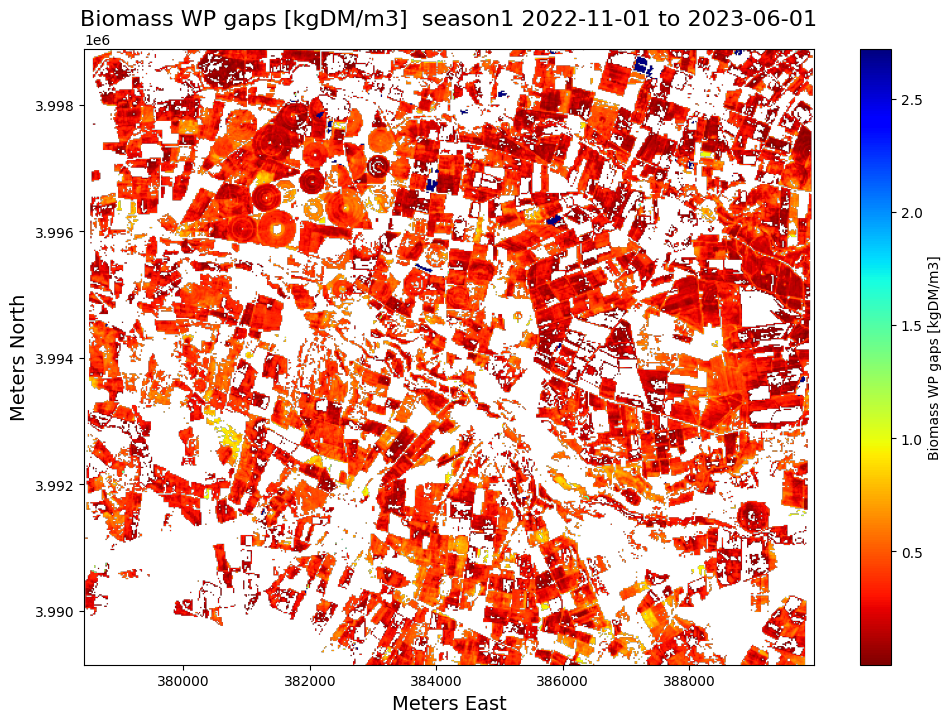

In [24]:

for in_fhWPb in input_WPbfhs:
    # Open the WPb file with rioxarray
    WPb_ds = rioxarray.open_rasterio(in_fhWPb)

    # Convert to numpy array
    WPb = WPb_ds.values[0]  # assuming the first band is used

    # Productivity targets and productivity gaps
    WPb_1D = WPb.ravel()  # Reshape the array to 1D
    TargetWPb = round(np.nanpercentile(WPb_1D, TargetPercentile), 2)
    WPbgap = np.where(WPb < TargetWPb, TargetWPb - WPb, np.nan)

    # Add an extra dimension to match the expected shape (1, ysize, xsize)
    WPbgap = WPbgap[np.newaxis, :, :]

    # Identify the date from the file name
    date = os.path.basename(in_fhWPb).split('.')[0].replace('BWP', '').replace('_', ' ')

    # Check if 'pywapor' is in the file name, and remove it if it exists
    if 'pywapor' in date:
        date = date.replace('pywapor', '')

    # Save yield gap
    output_folder = output_folder2
    basename = os.path.basename(in_fhWPb).replace('BWP', 'WPbGaps')
    output_fn = os.path.join(output_folder, basename)

    # Save the WP gap as a GeoTIFF using rioxarray
    WPbgap_ds = WPb_ds.copy(data=WPbgap)
    WPbgap_ds.rio.to_raster(output_fn)

    spatial_extent = (WPb_ds.x.min(), WPb_ds.x.max(), WPb_ds.y.min(), WPb_ds.y.max())

    # Plot the raster map
    plt.figure(figsize=(12, 8))
    plt.imshow(WPbgap[0], cmap='jet_r', vmin=np.nanmin(WPbgap), vmax=np.nanmax(WPbgap), extent=spatial_extent)
    plt.colorbar(shrink=1, label='Biomass WP gaps [kgDM/m3]')
    plt.xlabel('Meters East', fontsize=14)
    plt.ylabel('Meters North', fontsize=14)
    plt.title('Biomass WP gaps [kgDM/m3] ' + date, fontsize=16)
    plt.show()


### **ii) Crop yield gaps and crop water productivity gaps**

## * Import the input data (yield and WPy raster data)

In [25]:
# Import relevant data
input_Yieldfolder  = os.path.join(dir_proj, dir_data, "yield_season")
input_Yieldfhs     = sorted(glob.glob(input_Yieldfolder + '/*.tif'))

input_WPyfolder   = os.path.join(dir_proj, dir_data, "Cwp_season")
input_WPyfhs      = sorted(glob.glob(input_WPyfolder + '/*.tif'))

# Verify input files
verify_file_paths('Yield', input_Yieldfolder, input_Yieldfhs)
verify_file_paths('cWP', input_WPyfolder, input_WPyfhs)

## ** Output folder: Make one or connect to the existing one

In [26]:
# Create output folders
output_folder1 = os.path.join(dir_proj, dir_out, "YieldGaps")
output_folder2 = os.path.join(dir_proj, dir_out, "WPygaps")

for folder in [output_folder1, output_folder2]:
    os.makedirs(folder, exist_ok=True)

output_folder1, output_folder2

('/content/output/YieldGaps', '/content/output/WPygaps')

## ** Crop yield gaps

In [27]:
# Target productivity
TargetPercentile = 90

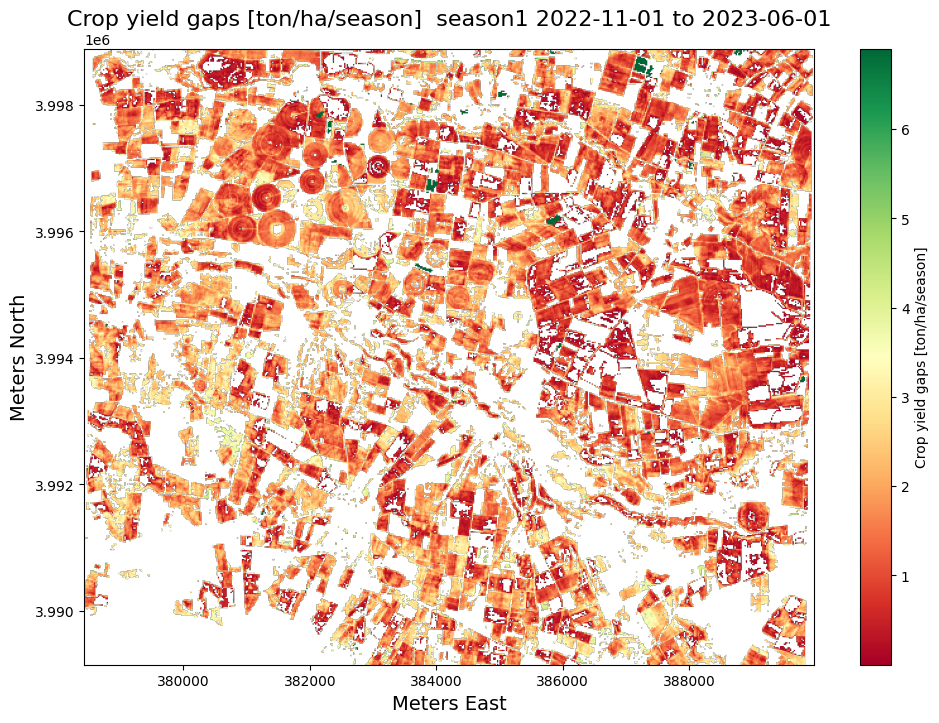

In [28]:
import rioxarray
import numpy as np
import os
import matplotlib.pyplot as plt

for in_fhYield in input_Yieldfhs:
    # Open the Yield file with rioxarray
    Yield_ds = rioxarray.open_rasterio(in_fhYield)

    # Convert to numpy array
    Yield = Yield_ds.values[0]  # assuming the first band is used

    # Productivity targets and productivity gaps
    Yield_1D = Yield.ravel()  # Reshape the array to 1D
    TargetYield = round(np.nanpercentile(Yield_1D, TargetPercentile), 1)
    Yieldgap = np.where(Yield < TargetYield, TargetYield - Yield, np.nan)

    # Add an extra dimension to match the expected shape (1, ysize, xsize)
    Yieldgap = Yieldgap[np.newaxis, :, :]

    # Identify the date from the file name
    date = os.path.basename(in_fhYield).split('.')[0].replace('yield', '').replace('_', ' ')

    # Check if 'pywapor' is in the file name, and remove it if it exists
    if 'pywapor' in date:
        date = date.replace('pywapor', '')

    # Save yield gap
    output_folder = output_folder1
    basename = os.path.basename(in_fhYield).replace('yield', 'YieldGaps')
    output_fn = os.path.join(output_folder, basename)

    # Save the Yield gap as a GeoTIFF using rioxarray
    Yieldgap_ds = Yield_ds.copy(data=Yieldgap)
    Yieldgap_ds.rio.to_raster(output_fn)

    spatial_extent = (Yield_ds.x.min(), Yield_ds.x.max(), Yield_ds.y.min(), Yield_ds.y.max())

    # Plot the raster map
    plt.figure(figsize=(12, 8))
    plt.imshow(Yieldgap[0], cmap='RdYlGn', vmin=np.nanmin(Yieldgap), vmax=np.nanmax(Yieldgap), extent=spatial_extent)
    plt.colorbar(shrink=1, label='Crop yield gaps [ton/ha/season]')
    plt.xlabel('Meters East', fontsize=14)
    plt.ylabel('Meters North', fontsize=14)
    plt.title('Crop yield gaps [ton/ha/season] ' + date, fontsize=16)
    plt.show()


## *** Crop WP gaps

In [29]:
# Define target productivity
TargetPercentile = 90

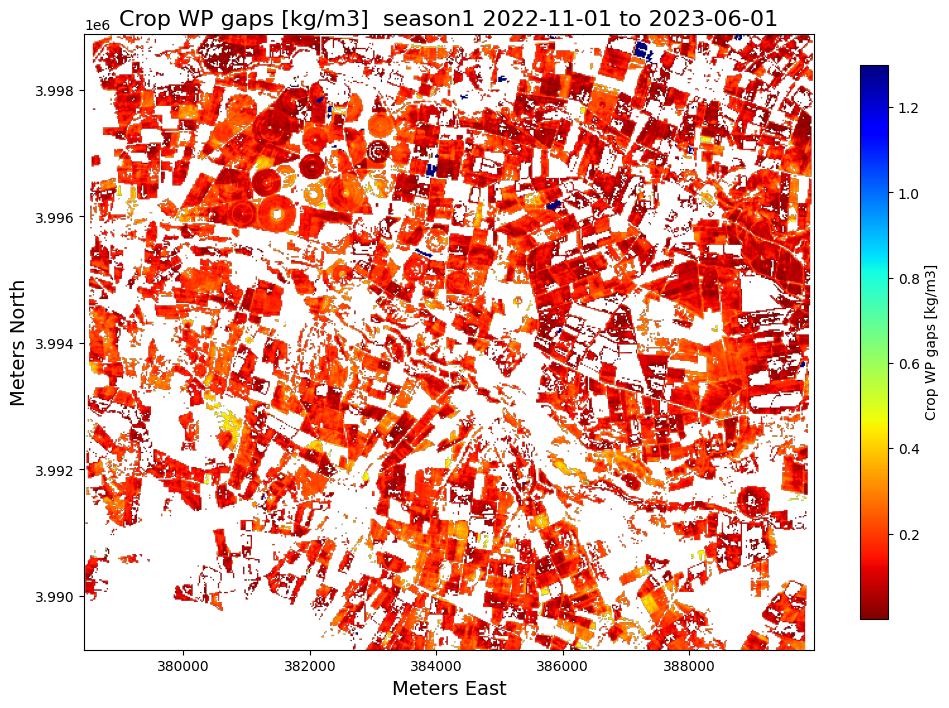

In [30]:

# Read spatial information from the first input file using rioxarray
in_fh = input_WPyfhs[0]

for in_fhWPy in input_WPyfhs:
    # Open the WPy file with rioxarray
    WPy_ds = rioxarray.open_rasterio(in_fhWPy)

    # Convert to numpy array
    WPy = WPy_ds.values[0]  # assuming the first band is used

    # Productivity targets and productivity gaps
    WPy_1D = WPy.ravel()  # Reshape the array to 1D
    TargetWPy = round(np.nanpercentile(WPy_1D, TargetPercentile), 2)
    WPygap = np.where(WPy < TargetWPy, TargetWPy - WPy, np.nan)

    # Add an extra dimension to match the expected shape (1, ysize, xsize)
    WPygap = WPygap[np.newaxis, :, :]

    # Identify the date from the file name
    date = os.path.basename(in_fhWPy).split('.')[0].replace('cWP', '').replace('_', ' ')

    # Check if 'pywapor' is in the file name, and remove it if it exists
    if 'pywapor' in date:
        date = date.replace('pywapor', '')

    # Save yield gap
    output_folder = output_folder2
    basename = os.path.basename(in_fhWPy).replace('cWP', 'WPyGaps')
    output_fn = os.path.join(output_folder, basename)

    # Save the WPy gap as a GeoTIFF using rioxarray
    WPygap_ds = WPy_ds.copy(data=WPygap)
    WPygap_ds.rio.to_raster(output_fn)

    spatial_extent = (WPy_ds.x.min(), WPy_ds.x.max(), WPy_ds.y.min(), WPy_ds.y.max())

    # Plot the raster map
    plt.figure(figsize=(12, 8))
    plt.imshow(WPygap[0], cmap='jet_r', vmin=np.nanmin(WPygap), vmax=np.nanmax(WPygap), extent=spatial_extent)
    plt.colorbar(shrink=0.9, label='Crop WP gaps [kg/m3]')
    plt.xlabel('Meters East', fontsize=14)
    plt.ylabel('Meters North', fontsize=14)
    plt.title('Crop WP gaps [kg/m3] ' + date, fontsize=16)
    plt.show()


## **6 Download file**

In [31]:
# 1) Compress the specified folders into a single zip file
output_path = os.path.join(dir_proj, dir_out)
!zip -r {output_path}/ProductivityGaps.zip {output_path}/

# 2) Download the zipped file from Colab to your local machine
from google.colab import files
files.download(os.path.join(output_path, "ProductivityGaps.zip"))

  adding: content/output/ (stored 0%)
  adding: content/output/YieldGaps/ (stored 0%)
  adding: content/output/YieldGaps/YieldGaps_season1_2022-11-01_to_2023-06-01.tif (deflated 49%)
  adding: content/output/WPygaps/ (stored 0%)
  adding: content/output/WPygaps/WPyGaps_season1_2022-11-01_to_2023-06-01.tif (deflated 50%)
  adding: content/output/BiomassGaps/ (stored 0%)
  adding: content/output/BiomassGaps/BiomassGaps_season1_2022-11-01_to_2023-06-01.tif (deflated 49%)
  adding: content/output/WPbgaps/ (stored 0%)
  adding: content/output/WPbgaps/WPbGaps_season1_2022-11-01_to_2023-06-01.tif (deflated 50%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>